In [37]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import os
import glob
import warnings

import joblib
import kagglehub
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

plt.style.use("ggplot")

In [38]:
# ==========================================================
# DOWNLOAD DATASET
# ==========================================================

path = kagglehub.dataset_download(
    "raphaelnazareth/indonesia-financial-time-series-dataset-2010-2026"
)

csv = glob.glob(os.path.join(path,"*.csv"))[0]

df = pd.read_csv(csv)

print(df.head())

Using Colab cache for faster access to the 'indonesia-financial-time-series-dataset-2010-2026' dataset.
         Date        OIL         GOLD       USDIDR        SP500         IHSG  \
0  2010-01-01        NaN          NaN  9385.599609          NaN          NaN   
1  2010-01-04  81.510002  1117.699951  9364.200195  1132.989990  2575.312988   
2  2010-01-05  81.769997  1118.099976  9305.200195  1136.520020  2605.175537   
3  2010-01-06  83.180000  1135.900024  9218.099609  1137.140015  2603.195557   
4  2010-01-07  82.660004  1133.099976  9272.500000  1141.689941  2586.794189   

         VIX       CPI  BI_rate  US_rate  
0        NaN  5.134206      6.5     0.11  
1  20.040001  5.134206      6.5     0.11  
2  19.350000  5.134206      6.5     0.11  
3  19.160000  5.134206      6.5     0.11  
4  19.059999  5.134206      6.5     0.11  


## Pra pemrosesan

In [39]:
# ==========================================================
# DATA CLEANING
# ==========================================================


df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df = df.reset_index(drop=True)

daily_cols = [
    "USDIDR",
    "OIL",
    "GOLD",
    "SP500",
    "IHSG",
    "VIX"
]

df[daily_cols] = df[daily_cols].interpolate()

monthly_cols = [
    "CPI",
    "BI_rate",
    "US_rate"
]

df[monthly_cols] = df[monthly_cols].ffill()

print(df.isnull().sum())

Date       0
OIL        1
GOLD       1
USDIDR     0
SP500      1
IHSG       1
VIX        1
CPI        0
BI_rate    0
US_rate    0
dtype: int64


In [40]:
df = df.dropna().reset_index(drop=True)

print(df.isnull().sum())

Date       0
OIL        0
GOLD       0
USDIDR     0
SP500      0
IHSG       0
VIX        0
CPI        0
BI_rate    0
US_rate    0
dtype: int64


In [41]:
# ==========================================================
# FEATURING ENGINEERING
# ==========================================================

df["USDIDR_Lag1"] = df["USDIDR"].shift(1)
df["USDIDR_Lag7"] = df["USDIDR"].shift(7)
df["USDIDR_Lag30"] = df["USDIDR"].shift(30)

df["USDIDR_MA7"] = (
    df["USDIDR"]
    .rolling(7)
    .mean()
)

df["USDIDR_MA30"] = (
    df["USDIDR"]
    .rolling(30)
    .mean()
)

df["USDIDR_STD7"] = (
    df["USDIDR"]
    .rolling(7)
    .std()
)

df["OIL_Lag1"] = df["OIL"].shift(1)
df["OIL_Lag7"] = df["OIL"].shift(7)

df["GOLD_Lag1"] = df["GOLD"].shift(1)

df["IHSG_Lag1"] = df["IHSG"].shift(1)

df["SP500_Lag1"] = df["SP500"].shift(1)

df["VIX_Lag1"] = df["VIX"].shift(1)

df = df.dropna()


In [42]:
# ==========================================================
# TARGET
# ==========================================================

TARGET = "USDIDR"
FEATURES = [
    "USDIDR",
    "OIL",
    "GOLD",
    "SP500",
    "IHSG",
    "VIX",
    "CPI",
    "BI_rate",
    "US_rate",

    "USDIDR_Lag1",
    "USDIDR_Lag7",
    "USDIDR_Lag30",

    "OIL_Lag1",
    "OIL_Lag7",

    "GOLD_Lag1",

    "SP500_Lag1",

    "IHSG_Lag1",

    "VIX_Lag1"
]

In [43]:
# ==========================================================
# SCALING
# ==========================================================

feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

X = feature_scaler.fit_transform(df[FEATURES])

y = target_scaler.fit_transform(
    df[[TARGET]]
)



In [44]:
# ==========================================================
# CREATE SEQUENCE
# ==========================================================

TIME_STEPS = 30

def create_sequences(X, y, time_steps):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:i + time_steps])
        ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)


X_seq, y_seq = create_sequences(
    X,
    y,
    TIME_STEPS
)

print("Shape X :", X_seq.shape)
print("Shape y :", y_seq.shape)

Shape X : (4216, 30, 18)
Shape y : (4216, 1)


In [45]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
X_test  = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test  = y_seq[train_size:]

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (3372, 30, 18)
Test  : (844, 30, 18)


In [46]:
print(X_train.shape)
print(y_train.shape)

(3372, 30, 18)
(3372, 1)


## Model GRU

In [48]:
# ==========================================================
# BUILD GRU MODEL
# ==========================================================

model = Sequential([

    GRU(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.2),

    GRU(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

Compile Model

In [49]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.Huber(),

    metrics=[
        "mae",
        "mse"
    ]
)

In [50]:
import os

if os.path.exists("best_gru.keras"):
    os.remove("best_gru.keras")

Callback

In [51]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=8,

    min_lr=1e-6
)

checkpoint = ModelCheckpoint(

    "best_gru.keras",

    monitor="val_loss",

    save_best_only=True
)

Training (biasanya lama jadi sabar)

ada data yang aneh

In [52]:
df = df[df["USDIDR"] > 5000].copy()
df.reset_index(drop=True, inplace=True)

In [53]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

print("TIME_STEPS :", TIME_STEPS)

print("FEATURES :", len(FEATURES))
print(FEATURES)

X_train : (3372, 30, 18)
X_test : (844, 30, 18)
y_train : (3372, 1)
y_test : (844, 1)
TIME_STEPS : 30
FEATURES : 18
['USDIDR', 'OIL', 'GOLD', 'SP500', 'IHSG', 'VIX', 'CPI', 'BI_rate', 'US_rate', 'USDIDR_Lag1', 'USDIDR_Lag7', 'USDIDR_Lag30', 'OIL_Lag1', 'OIL_Lag7', 'GOLD_Lag1', 'SP500_Lag1', 'IHSG_Lag1', 'VIX_Lag1']


In [54]:
print(df.head())
print(df.tail())

        Date        OIL         GOLD       USDIDR        SP500         IHSG  \
0 2010-02-15  74.129997  1089.500000  9344.799805  1075.510010  2517.358154   
1 2010-02-16  77.010002  1119.300049  9292.900391  1094.869995  2558.405273   
2 2010-02-17  77.330002  1119.500000  9400.599609  1099.510010  2581.239746   
3 2010-02-18  79.059998  1118.000000  9499.799805  1106.750000  2559.934326   
4 2010-02-19  79.809998  1121.300049  9292.200195  1109.170044  2554.276367   

         VIX       CPI  BI_rate  US_rate  ...  USDIDR_Lag30   USDIDR_MA7  \
0  22.730000  5.134206      6.5     0.13  ...   9364.200195  9372.128488   
1  22.250000  5.134206      6.5     0.13  ...   9305.200195  9347.100028   
2  21.719999  5.134206      6.5     0.13  ...   9218.099609  9335.114258   
3  20.629999  5.134206      6.5     0.13  ...   9272.500000  9358.042829   
4  20.020000  5.134206      6.5     0.13  ...   9212.700195  9354.871373   

   USDIDR_MA30  USDIDR_STD7   OIL_Lag1   OIL_Lag7    GOLD_Lag1    IH

In [55]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=200,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1
)

Epoch 1/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 0.0107 - mae: 0.1059 - mse: 0.0213 - val_loss: 0.0014 - val_mae: 0.0484 - val_mse: 0.0028 - learning_rate: 0.0010
Epoch 2/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0034 - mae: 0.0644 - mse: 0.0068 - val_loss: 7.0250e-04 - val_mae: 0.0339 - val_mse: 0.0014 - learning_rate: 0.0010
Epoch 3/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0026 - mae: 0.0564 - mse: 0.0052 - val_loss: 0.0017 - val_mae: 0.0577 - val_mse: 0.0035 - learning_rate: 0.0010
Epoch 4/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0020 - mae: 0.0492 - mse: 0.0041 - val_loss: 0.0011 - val_mae: 0.0437 - val_mse: 0.0022 - learning_rate: 0.0010
Epoch 5/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 0.0018 - mae: 0.0451 - mse: 0.0035 - val_loss: 0.0024 - val_mae: 0.0674 - val_mse: 0.0049 - learning_rate: 0.0010
Epoch 6/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0015 - mae: 0.0415 - mse: 0.0030 - val_loss: 0.0021 - val_mae: 

In [56]:
y_pred_scaled = model.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [57]:
y_pred = target_scaler.inverse_transform(y_pred_scaled)

y_true = target_scaler.inverse_transform(y_test)

In [58]:
print("y_pred_scaled :", y_pred_scaled.min(), y_pred_scaled.max())
print("y_test :", y_test.min(), y_test.max())

print("y_pred :", y_pred.min(), y_pred.max())
print("y_true :", y_true.min(), y_true.max())

y_pred_scaled : 0.84896475 0.9842382
y_test : 0.8125872691921256 0.9999999999999999
y_pred : 15279.667 17572.809
y_true : 14663.0 17840.0


In [59]:
print("Train USDIDR:")
print(df.iloc[:train_size]["USDIDR"].min(),
      df.iloc[:train_size]["USDIDR"].max())

print("Test USDIDR:")
print(df.iloc[train_size:]["USDIDR"].min(),
      df.iloc[train_size:]["USDIDR"].max())

Train USDIDR:
8292.7001953125 16504.80078125
Test USDIDR:
14663.0 17840.0


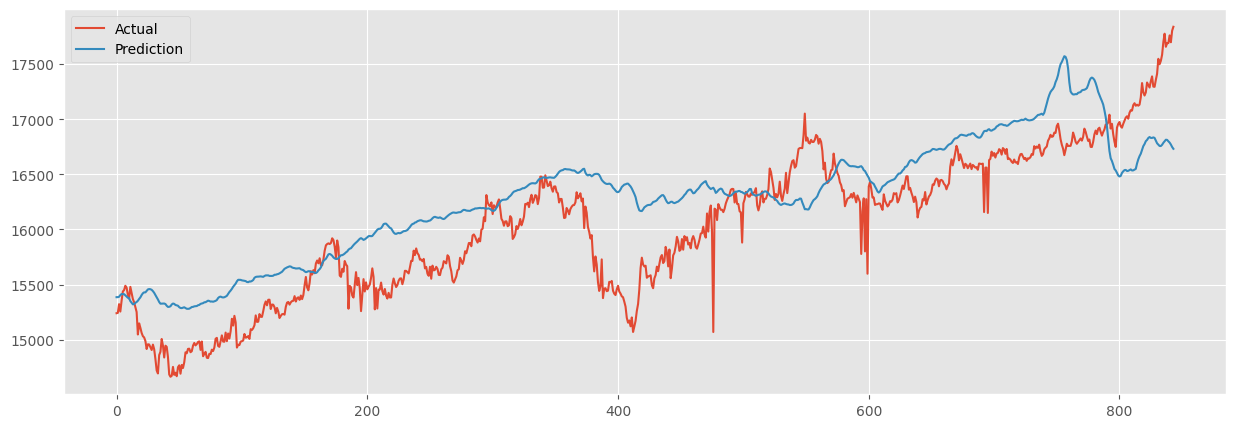

In [60]:
plt.figure(figsize=(15,5))
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Prediction")
plt.legend()
plt.show()

In [61]:
print(df[["Date", "USDIDR"]].nsmallest(10, "USDIDR"))

          Date       USDIDR
390 2011-08-16  8292.700195
382 2011-08-04  8325.200195
394 2011-08-22  8339.299805
391 2011-08-17  8358.700195
369 2011-07-18  8366.099609
326 2011-05-18  8372.700195
392 2011-08-18  8374.200195
405 2011-09-06  8379.500000
349 2011-06-20  8386.799805
404 2011-09-05  8402.000000


### Hitung metrik

In [62]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

r2 = r2_score(
    y_true,
    y_pred
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 370.14
RMSE : 438.76
R²   : 0.5594


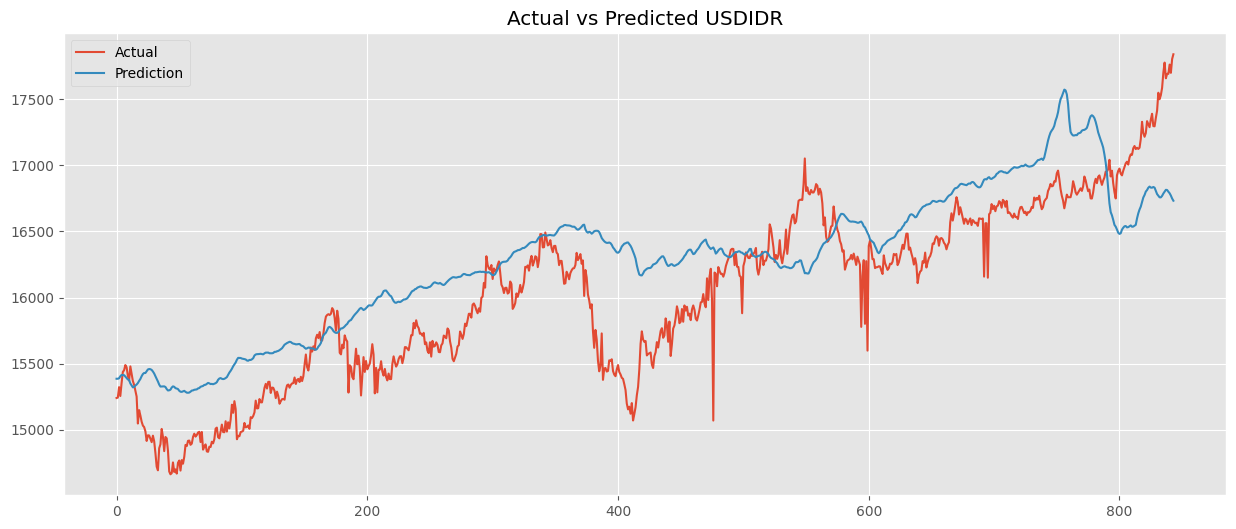

In [63]:
plt.figure(figsize=(15,6))

plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Prediction")

plt.legend()
plt.title("Actual vs Predicted USDIDR")
plt.show()

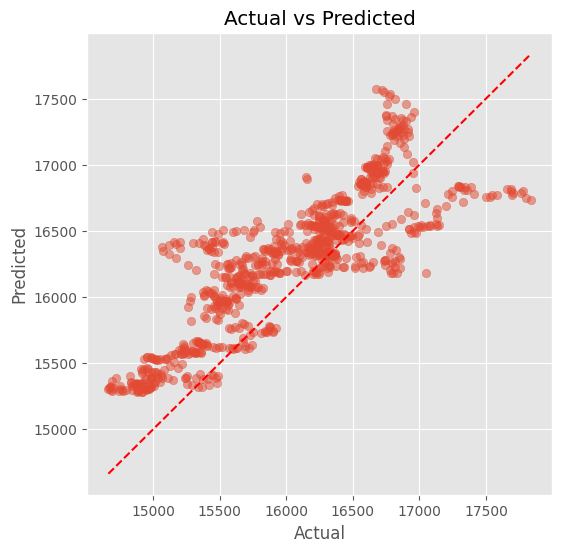

In [64]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

## Simpan model

In [70]:
import joblib

# Simpan model
model.save("gru_usdidr.keras")

# Simpan scaler
joblib.dump(feature_scaler, "feature_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

# Simpan fitur
joblib.dump(FEATURES, "features.pkl")

# Simpan timesteps
joblib.dump(TIME_STEPS, "timesteps.pkl")

print("Semua file berhasil disimpan!")

Semua file berhasil disimpan!


In [71]:
import os

print(os.getcwd())

/content
